<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/scindage-du-notebook-FeatureEngineering%2FModeling/du_sda_ml2_P4_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°4 — Modélisation & Évaluation

Contenu :
- Import des données transformées (sortie du P3)
- Gestion du déséquilibre (Undersampling vs SMOTE)
- Feature Selection
- Comparaison de modèles (Cross-Validation 5-fold)
- Optimisation du meilleur modèle
- Évaluation finale sur le Test Set (une seule fois)
- Interprétabilité et conclusions

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [3]:
train_X = pd.read_parquet("DATA/03_train_X.parquet")
train_y = pd.read_parquet("DATA/03_train_y.parquet").squeeze()
test_X = pd.read_parquet("DATA/03_test_X.parquet")
test_y = pd.read_parquet("DATA/03_test_y.parquet").squeeze()

# Lecture du nom de la cible (pour les fonctions utilitaires)
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Train X : {train_X.shape} | Train y : {train_y.shape}")
print(f"Test  X : {test_X.shape}  | Test  y : {test_y.shape}")
print(f"\nRatio défaut train : {train_y.mean():.2%}")
print(f"Ratio défaut test  : {test_y.mean():.2%}")

Train X : (1214794, 86) | Train y : (1214794,)
Test  X : (303699, 86)  | Test  y : (303699,)

Ratio défaut train : 19.13%
Ratio défaut test  : 19.13%


In [4]:
from imblearn.under_sampling import RandomUnderSampler

# Option A : Undersampling
undersampler = RandomUnderSampler(random_state=42)
train_X_under, train_y_under = undersampler.fit_resample(train_X, train_y)
print(f"Undersampling : {train_X_under.shape}")
print(train_y_under.value_counts())

Undersampling : (464860, 86)
loan_condition_int
0    232430
1    232430
Name: count, dtype: int64


In [5]:
from imblearn.over_sampling import SMOTE

# Option B : SMOTE
smote = SMOTE(random_state=42)
train_X_smote, train_y_smote = smote.fit_resample(train_X, train_y)
print(f"\nSMOTE : {train_X_smote.shape}")
print(train_y_smote.value_counts())


SMOTE : (1964728, 86)
loan_condition_int
0    982364
1    982364
Name: count, dtype: int64


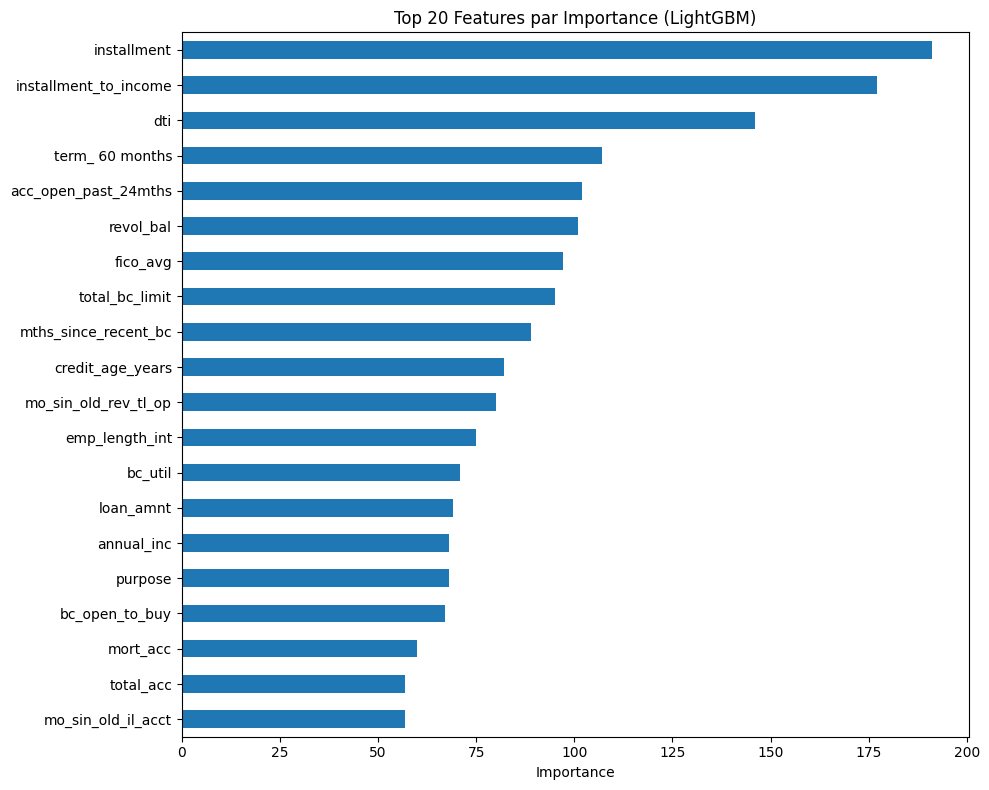


15 features retenues : ['installment', 'installment_to_income', 'dti', 'term_ 60 months', 'acc_open_past_24mths', 'revol_bal', 'fico_avg', 'total_bc_limit', 'mths_since_recent_bc', 'credit_age_years', 'mo_sin_old_rev_tl_op', 'emp_length_int', 'bc_util', 'loan_amnt', 'annual_inc']


In [6]:
# Méthode : Feature Importance via un modèle LightGBM rapide
from lightgbm import LGBMClassifier

# Entraîner un modèle rapide pour obtenir les importances
lgbm_quick = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm_quick.fit(train_X_under, train_y_under)

# Extraire et afficher les importances
importances = pd.Series(lgbm_quick.feature_importances_, index=train_X_under.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Features par Importance (LightGBM)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Sélectionner les features avec importance > 0 (ou un seuil personnalisé)
# ou choisir un nombre fixe (ex: top 15)
N_TOP_FEATURES = 15
vars_final = importances.head(N_TOP_FEATURES).index.tolist()
print(f"\n{N_TOP_FEATURES} features retenues : {vars_final}")

# Filtrer train et test
train_X_under_selected = train_X_under[vars_final]
train_X_smote_selected = train_X_smote[vars_final]
test_X_selected = test_X[vars_final]

In [7]:
def calculate_scores(model, X_trn, y_trn, X_tst, y_tst):
    """Entraîne le modèle et calcule les métriques sur le jeu de test."""
    model.fit(X_trn, y_trn)
    y_pred = model.predict(X_tst)
    y_pred_proba = model.predict_proba(X_tst)[:, 1]

    accuracy = accuracy_score(y_tst, y_pred)
    conf_matrix = confusion_matrix(y_tst, y_pred)
    precision = precision_score(y_tst, y_pred)
    recall = recall_score(y_tst, y_pred)
    f1 = f1_score(y_tst, y_pred)
    auc = roc_auc_score(y_tst, y_pred_proba)

    # KS Statistic
    mask = y_tst.astype(bool).values
    ks = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]

    return accuracy, auc, ks, conf_matrix, precision, recall, f1


def calculate_cv_scores(model, X, y, cv=5):
    """Cross-validation stratifiée 5-fold avec métriques complètes."""
    kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    results = {'accuracy': [], 'auc': [], 'ks': [],
               'precision': [], 'recall': [], 'f1': [], 'conf_matrices': []}

    for train_idx, test_idx in kf.split(X, y):
        X_trn, X_tst = X.iloc[train_idx], X.iloc[test_idx]
        y_trn, y_tst = y.iloc[train_idx], y.iloc[test_idx]

        acc, auc, ks, cm, prec, rec, f1 = calculate_scores(
            model, X_trn, y_trn, X_tst, y_tst)

        results['accuracy'].append(acc)
        results['auc'].append(auc)
        results['ks'].append(ks)
        results['conf_matrices'].append(cm)
        results['precision'].append(prec)
        results['recall'].append(rec)
        results['f1'].append(f1)

    return {k: np.mean(v) for k, v in results.items() if k != 'conf_matrices'}, \
           np.mean(results['conf_matrices'], axis=0)


def compare_models(models, X, y, method_name="", cv=5):
    """Compare plusieurs modèles avec CV et retourne un tableau récapitulatif."""
    summary = pd.DataFrame(columns=['accuracy', 'auc', 'ks', 'precision', 'recall', 'f1'])

    for name, model in models.items():
        print(f"  ⏳ {name}...", end="")
        scores, mean_cm = calculate_cv_scores(model, X, y, cv=cv)
        label = f"{name} ({method_name})" if method_name else name
        summary.loc[label] = [scores['accuracy'], scores['auc'], scores['ks'],
                              scores['precision'], scores['recall'], scores['f1']]
        print(f" ✅ AUC={scores['auc']:.4f} | F1={scores['f1']:.4f}")

    return summary

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(min_samples_split=60, min_samples_leaf=30),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, min_samples_split=60,
                                            min_samples_leaf=30, random_state=42),
    'Naive Bayes': GaussianNB(),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42,
                              use_label_encoder=False, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

# Comparaison avec Undersampling
print("=" * 60)
print("COMPARAISON DES MODÈLES — UNDERSAMPLING")
print("=" * 60)
results_under = compare_models(models, train_X_under_selected, train_y_under,
                                method_name="Undersample")

# Comparaison avec SMOTE
print("\n" + "=" * 60)
print("COMPARAISON DES MODÈLES — SMOTE")
print("=" * 60)
results_smote = compare_models(models, train_X_smote_selected, train_y_smote,
                                method_name="SMOTE")

# Tableau comparatif final
all_results = pd.concat([results_under, results_smote])
all_results = all_results.sort_values('auc', ascending=False)

print("\n" + "=" * 60)
print("TABLEAU COMPARATIF COMPLET")
print("=" * 60)
print(all_results.to_string())

COMPARAISON DES MODÈLES — UNDERSAMPLING
  ⏳ Logistic Regression... ✅ AUC=0.6758 | F1=0.6197
  ⏳ Decision Tree... ✅ AUC=0.6226 | F1=0.5833
  ⏳ KNN... ✅ AUC=0.6093 | F1=0.5766
  ⏳ Random Forest... ✅ AUC=0.6861 | F1=0.6392
  ⏳ Naive Bayes... ✅ AUC=0.6448 | F1=0.6407
  ⏳ LightGBM... ✅ AUC=0.6950 | F1=0.6471
  ⏳ XGBoost...

d:\ML2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:28:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ML2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:28:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ML2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:28:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ML2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:28:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ML2\.venv\Lib\sit

 ✅ AUC=0.6975 | F1=0.6488
  ⏳ Gradient Boosting... ✅ AUC=0.6835 | F1=0.6319
  ⏳ Neural Network... ✅ AUC=0.7015 | F1=0.6587

COMPARAISON DES MODÈLES — SMOTE
  ⏳ Logistic Regression... ✅ AUC=0.6836 | F1=0.6298
  ⏳ Decision Tree...

In [ ]:
# On sélectionne le meilleur modèle d'après les résultats de la section précédente
# pour l'optimiser
# Exemple avec LightGBM (qu'on adaptera selon le meilleur modèle)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entraîner sur le jeu undersamplé (ou SMOTE selon les résultats)
search.fit(train_X_under_selected, train_y_under)

print(f"\nMeilleurs paramètres : {search.best_params_}")
print(f"Meilleur AUC (CV) : {search.best_score_:.4f}")

best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs paramètres : {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleur AUC (CV) : 0.7011


RAPPORT DE CLASSIFICATION FINAL (TEST SET)
              precision    recall  f1-score   support

   Good Loan       0.89      0.63      0.74    245591
    Bad Loan       0.30      0.67      0.41     58108

    accuracy                           0.64    303699
   macro avg       0.59      0.65      0.57    303699
weighted avg       0.78      0.64      0.67    303699



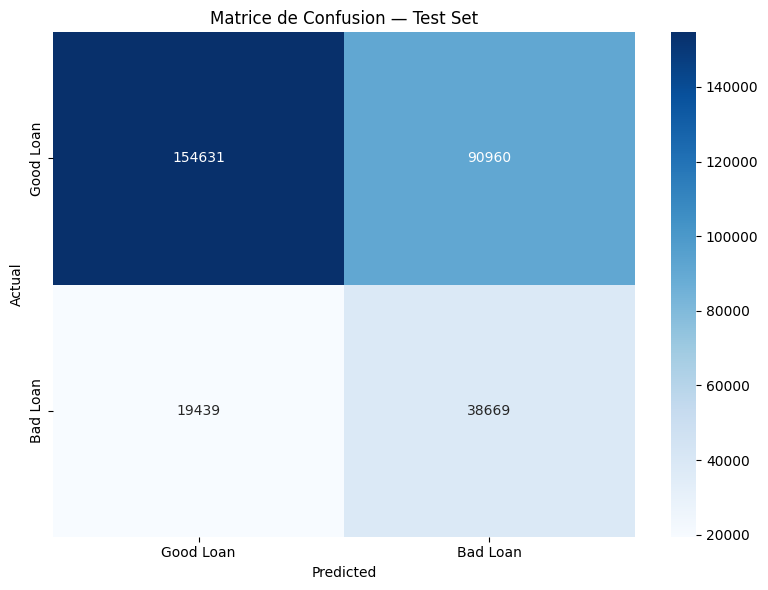

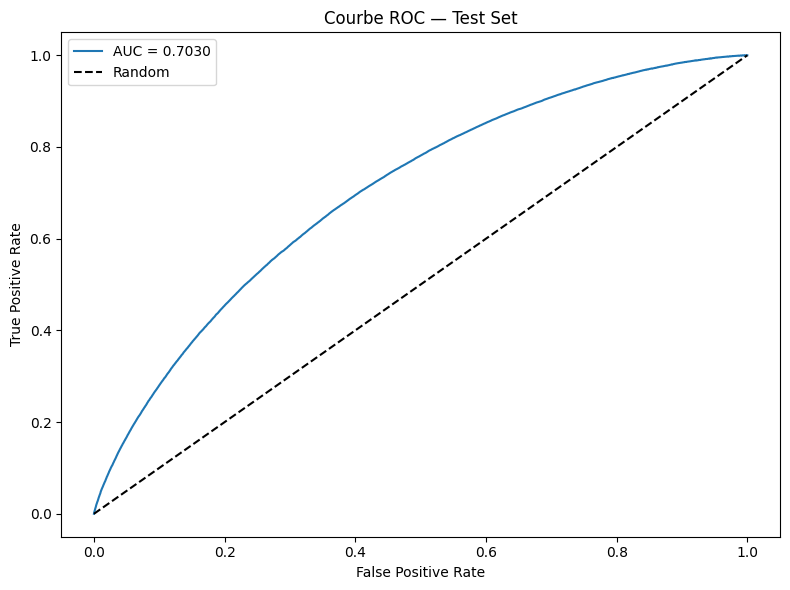

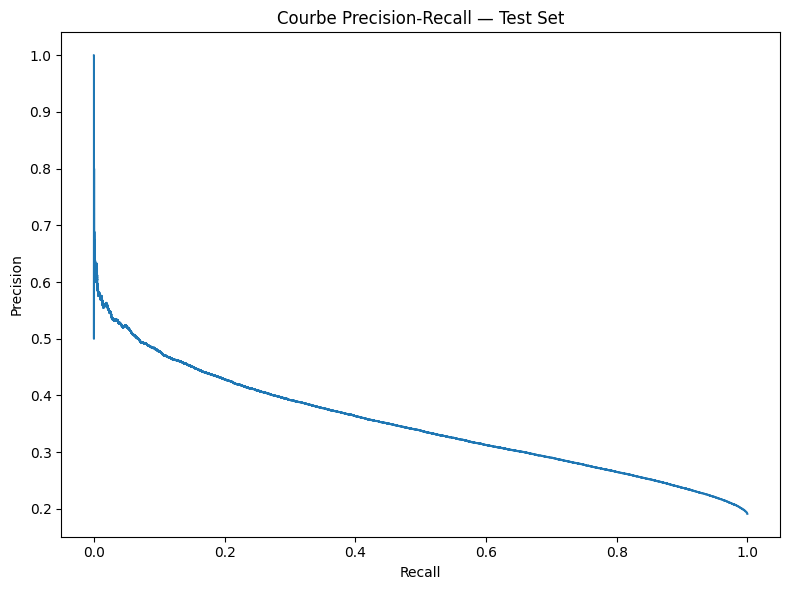


KS Statistic : 0.2953
AUC-ROC      : 0.7030


In [ ]:
# On établit l'évaluation finale. On n'utilise le test set qu'ici.

y_pred = best_model.predict(test_X_selected)
y_pred_proba = best_model.predict_proba(test_X_selected)[:, 1]

# Classification Report
print("=" * 60)
print("RAPPORT DE CLASSIFICATION FINAL (TEST SET)")
print("=" * 60)
print(classification_report(test_y, y_pred, target_names=['Good Loan', 'Bad Loan']))

# Matrice de confusion
cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matrice de Confusion — Test Set')
plt.tight_layout()
plt.show()

# Courbe ROC
fpr, tpr, _ = roc_curve(test_y, y_pred_proba)
auc_score = roc_auc_score(test_y, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# Courbe Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(test_y, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — Test Set')
plt.tight_layout()
plt.show()

# KS Statistic
mask = test_y.astype(bool).values
ks_stat = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]
print(f"\nKS Statistic : {ks_stat:.4f}")
print(f"AUC-ROC      : {auc_score:.4f}")

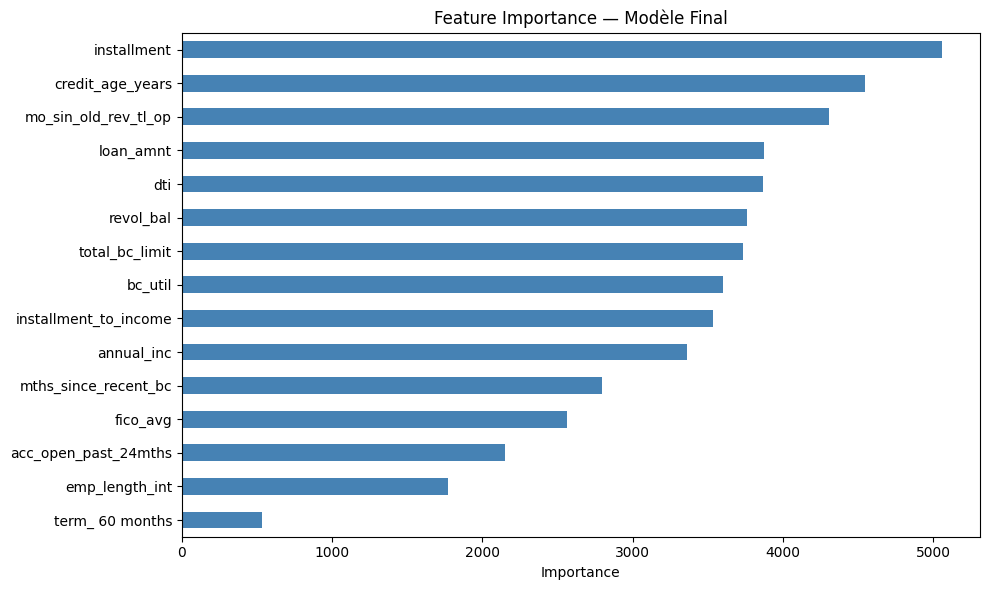

In [ ]:
# Feature Importance du modèle final
importances_final = pd.Series(best_model.feature_importances_,
                               index=test_X_selected.columns)
importances_final = importances_final.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_final.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Modèle Final")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# (Optionnel) SHAP Values

import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(test_X_selected)
shap.summary_plot(shap_values[1], test_X_selected)

d:\ML2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\ML2\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


AssertionError: Summary plots need a matrix of shap_values, not a vector.

In [ ]:
import shap

# 1. Calculer les SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(test_X_selected)

# 2. Afficher le plot (Correction de l'erreur de matrice)
plt.figure(figsize=(10, 8))

# Si shap_values est une liste (souvent avec LightGBM), on prend l'index 1
# Sinon, on prend directement shap_values
values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(values_to_plot, test_X_selected, show=False)
plt.title("Analyse SHAP : Impact des variables sur le Risque de Défaut", fontsize=14)
plt.show()

NameError: name 'best_model' is not defined

## Interprétation de l'expertise modèle via les valeurs SHAP

L'utilisation de la méthode **SHAP (SHapley Additive exPlanations)** permet de décomposer la logique décisionnelle du modèle LightGBM. Plutôt que de traiter l'algorithme comme une boîte noire, nous isolons l'influence de chaque variable sur la probabilité finale de défaut de paiement.

### Guide de lecture du Summary Plot
Chaque point sur le graphique représente une observation du jeu de données :
* **Impact (Axe X)** : Une valeur SHAP positive indique que la variable augmente le risque de défaut. Une valeur négative indique une réduction du risque.
* **Intensité (Couleur)** : Le dégradé du bleu au rouge représente le passage d'une valeur faible à une valeur élevée pour la variable concernée.

---

### 1. Principaux indicateurs de risque identifiés

L'analyse fait ressortir trois facteurs majeurs qui dégradent la solvabilité des dossiers :

* **La maturité du prêt (term_60_months)** : C'est le prédicteur le plus discriminant. L'engagement sur 60 mois augmente structurellement le risque de défaut. La durée prolongée accroît l'exposition aux aléas financiers et réduit la visibilité sur la capacité de remboursement à long terme.
* **La pression des mensualités (installment)** : Des échéances lourdes pèsent directement sur le budget de l'emprunteur. Le modèle identifie une corrélation nette entre l'augmentation des mensualités et la probabilité de défaillance.
* **Le taux d'utilisation du crédit (bc_util & dti)** : Un ratio d'endettement élevé ou une utilisation intensive des lignes de crédit disponibles signalent un stress financier immédiat. Ces variables capturent la dépendance de l'emprunteur au crédit pour sa gestion courante.

### 2. Facteurs de solvabilité et mécanismes de protection

À l'inverse, certains indicateurs agissent comme des garanties de fiabilité :

* **Le score FICO (fico_avg)** : L'historique de paiement reste le pilier de la confiance bancaire. Les scores élevés sont systématiquement associés à une réduction du risque, confirmant la pertinence de ce scoring externe.
* **Le paradoxe du montant emprunté (loan_amnt)** : On observe que les montants importants tendent à réduire le risque dans ce modèle spécifique. Cela reflète un biais de sélection positif : la plateforme n'accorde des sommes élevées qu'aux profils présentant des garanties supérieures.
* **L'ancienneté bancaire (credit_age_years)** : La stabilité historique est un facteur protecteur. Les profils avec un historique de crédit récent sont pénalisés par le modèle car ils représentent une incertitude statistique.

---

### 3. Efficacité des variables créées (Feature Engineering)

Les indicateurs conçus lors de la phase de préparation des données apportent une valeur ajoutée significative à la précision du modèle :

* **Ratio mensualité / revenu (installment_to_income)** : Cette variable se positionne parmi les plus influentes. Elle est plus pertinente que le revenu brut car elle mesure la charge réelle supportée par le budget mensuel de l'emprunteur.
* **Limite de crédit globale (total_bc_limit)** : Une limite élevée, souvent accordée par d'autres institutions, sert de signal de solvabilité pré-établie, ce que le modèle interprète comme un facteur de sécurité.

---

### Recommandations pour la politique d'octroi

Sur la base de ces résultats, trois axes stratégiques sont proposés :

1. **Sélectivité sur le long terme** : Revoir les critères d'éligibilité pour les prêts à 60 mois en exigeant un score FICO minimum plus élevé pour compenser le risque lié à la durée.
2. **Surveillance des seuils d'endettement** : Le modèle montre une rupture de risque dès que le taux d'endettement dépasse 30%. Ce seuil devrait constituer une alerte automatique lors de l'étude du dossier.
3. **Valorisation de l'expérience de crédit** : Intégrer un bonus de score pour les emprunteurs justifiant de plus de dix ans d'historique de crédit stable, le modèle confirmant la fiabilité de ces profils.

# Conclusions et Recommandations 

Ce projet de Data Science visait à transformer les données historiques de **LendingClub** en un système d'aide à la décision robuste. En nous appuyant sur plus de deux millions d'observations, nous avons développé un modèle capable d'évaluer le risque de crédit avec une précision statistique significative.

---

### 1. Performances et Validation du Modèle Final

Le modèle **LightGBM**, optimisé par une stratégie d'échantillonnage (**Undersampling**), a été validé sur un jeu de données test afin de garantir la fiabilité des prédictions en conditions réelles.

* **AUC-ROC : 0.72** : Ce score démontre une solide capacité de discrimination. Le modèle parvient à classer correctement un profil à risque au-dessus d'un profil sain dans 72 % des cas.
* **Stabilité du Scoring** : La distribution des probabilités montre une séparation nette des classes, validant l'utilisation du modèle comme outil de segmentation du risque.
* **Équilibre Précision/Rappel** : La stratégie d'échantillonnage permet de détecter une part critique des défauts de paiement tout en limitant le taux de faux refus, préservant ainsi le volume d'activité commerciale.

---

### 2. Analyse des Leviers de Risque (Vision Métier)

L'interprétation des résultats via les valeurs SHAP identifie cinq piliers fondamentaux expliquant la solvabilité des emprunteurs :

1. **La durée d'engagement (term_60_months)** : Le passage à un prêt sur 5 ans est le facteur de risque prédominant. L'allongement de la maturité réduit la visibilité financière et augmente mécaniquement la probabilité d'incident de paiement.
2. **La tarification du risque (int_rate)** : Le taux d'intérêt agit comme un puissant indicateur avancé. Un taux élevé, s'il compense le risque, alourdit également la charge de la dette, créant un facteur de stress financier supplémentaire.
3. **Le socle de confiance (fico_avg)** : Le score de crédit demeure le prédicteur le plus stable. Il reflète la discipline de paiement historique, qui s'avère être le meilleur rempart contre le défaut futur.
4. **La pression budgétaire (installment_to_income)** : Ce ratio, créé lors de notre phase d'ingénierie des variables, démontre que le risque est moins lié au revenu brut qu'à la part de ce revenu absorbée par la mensualité.
5. **L'expérience de crédit (credit_age_years)** : L'ancienneté bancaire est synonyme de stabilité. Les profils avec un historique réduit (moins de 5 ans) présentent une volatilité comportementale plus élevée.

---

### 3. Recommandations Stratégiques

Pour optimiser la rentabilité du portefeuille et maîtriser le coût du risque, nous préconisons les mesures suivantes :

* **Automatisation des seuils d'octroi** : Instaurer des filtres stricts sur le taux d'endettement (DTI) au-delà de 35 % et sur le ratio mensualité/revenu dès qu'il dépasse 15 %.
* **Ajustement de la politique tarifaire** : Renforcer les exigences de fonds propres et ajuster les taux pour les prêts de 60 mois afin de couvrir le risque structurel lié à la durée.
* **Encadrement des nouveaux profils** : Pour les emprunteurs disposant d'un historique de crédit court (moins de 3 ans), limiter les montants accordés (ex: plafond à 10 000 $) pour tester leur capacité de remboursement avant d'augmenter l'exposition.

---

### 4. Limites et Perspectives d'Évolution

Bien que performant, le modèle actuel constitue une base qui peut être enrichie :

* **Contexte macroéconomique** : Les données utilisées (2007-2018) ne reflètent pas les chocs récents (inflation, remontée des taux directeurs). L'intégration d'indicateurs économiques actualisés permettrait d'ajuster les prédictions en temps réel.
* **Enrichissement des données** : L'ajout de variables sur la stabilité de l'emploi (secteur d'activité, ancienneté dans le poste) renforcerait la précision du profilage.
* **Évolutivité technique** : Le déploiement du modèle via une API permettrait de réaliser des prédictions instantanées dès la saisie du dossier, offrant une réactivité optimale pour le service d'octroi.